In [4]:
import pandas as pd
from pathlib import Path

In [5]:
import sys
print(sys.executable)

c:\Users\anama\AppData\Local\Programs\Python\Python312\python.exe


# 1 - General

In [6]:
csv_path = Path("../data/raw/AB_NYC_2019.csv")

df = pd.read_csv(csv_path)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df = df.dropna(subset=["name", "host_name"])

In [9]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [10]:
df["last_review"] = pd.to_datetime(df["last_review"])
df["has_review"] = df["last_review"].notna()

In [11]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
has_review                            0
dtype: int64

# Outliners check

In [12]:
df.duplicated().sum()

0

In [13]:
df["price"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count    48858.000000
mean       152.740309
std        240.232386
min          0.000000
1%          30.000000
5%          40.000000
25%         69.000000
50%        106.000000
75%        175.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64

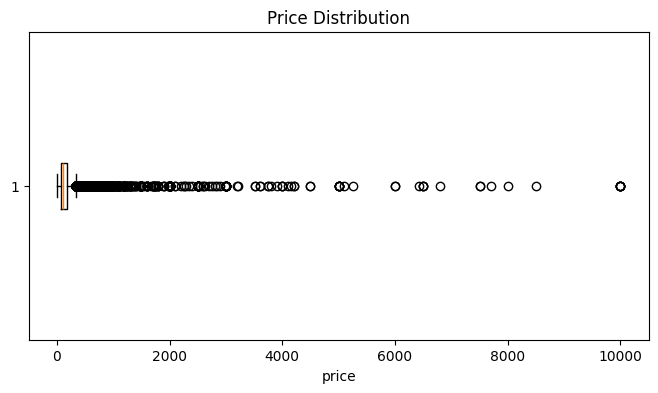

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df["price"], vert=False)
plt.title("Price Distribution")
plt.xlabel("price")
plt.show()

In [15]:
print((df["price"] == 0).sum())
print((df["price"] > 799).sum())

11
474


In [16]:
df = df[df["price"] > 0]
df["is_luxury"] = df["price"] > 799

# 3 - Distributions

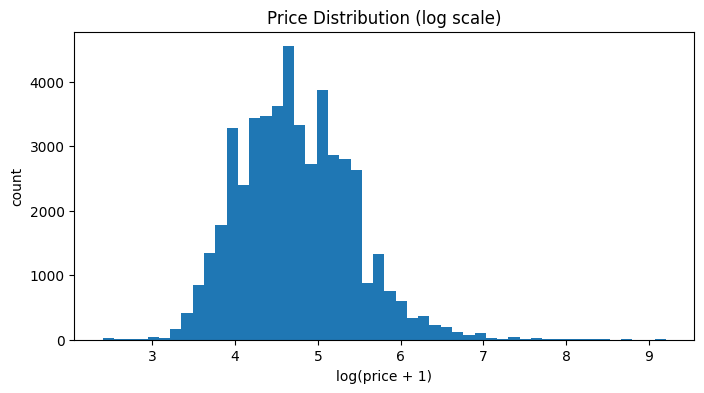

In [17]:
import numpy as np

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["price"]), bins=50)
plt.title("Price Distribution (log scale)")
plt.xlabel("log(price + 1)")
plt.ylabel("count")
plt.show()

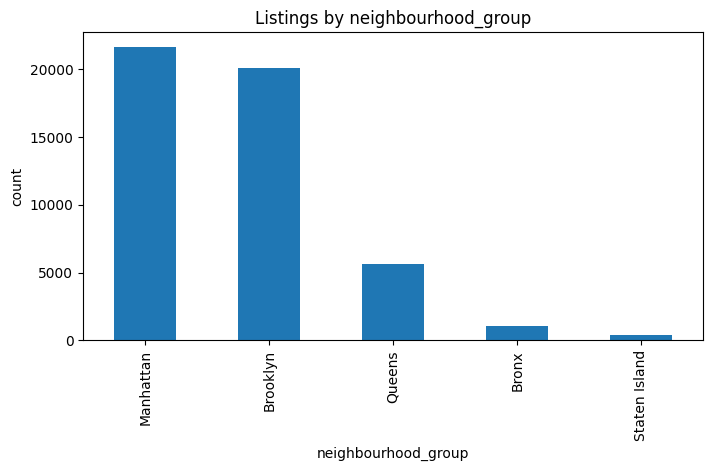

In [18]:
df["neighbourhood_group"].value_counts().plot(kind="bar", figsize=(8, 4), title="Listings by neighbourhood_group")
plt.ylabel("count")
plt.show()

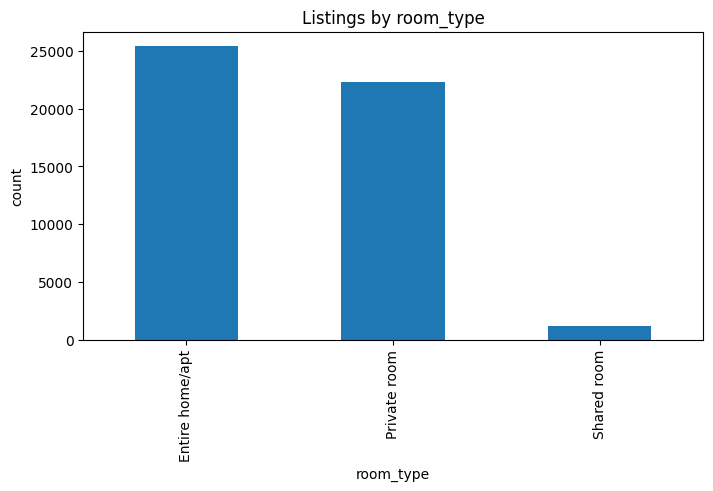

In [19]:
df["room_type"].value_counts().plot(kind="bar", figsize=(8, 4), title="Listings by room_type")
plt.ylabel("count")
plt.show()

# 4 - Relationships between variables

In [20]:
df.groupby("neighbourhood_group")["price"].agg(["mean", "median", "count"]).sort_values("median", ascending=False)

,mean,median,count
neighbourhood_group,,,
Manhattan,196.906571,150.0,21642
Brooklyn,124.466285,90.0,20080
Queens,99.536017,75.0,5664
Staten Island,114.812332,75.0,373
Bronx,87.549632,65.0,1088


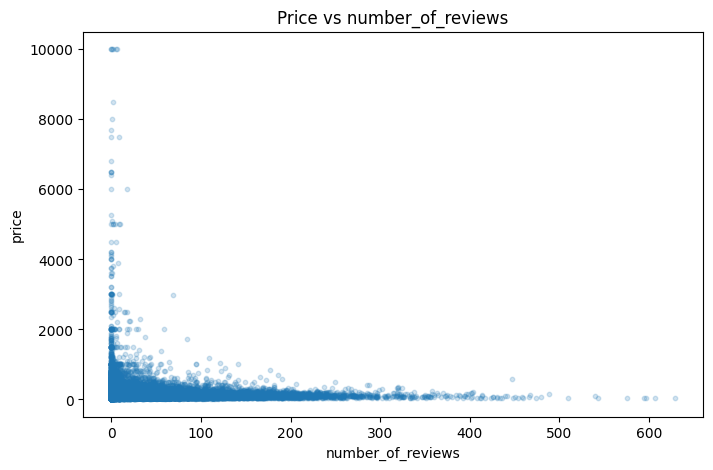

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df["number_of_reviews"], df["price"], alpha=0.2, s=10)
plt.title("Price vs number_of_reviews")
plt.xlabel("number_of_reviews")
plt.ylabel("price")
plt.show()

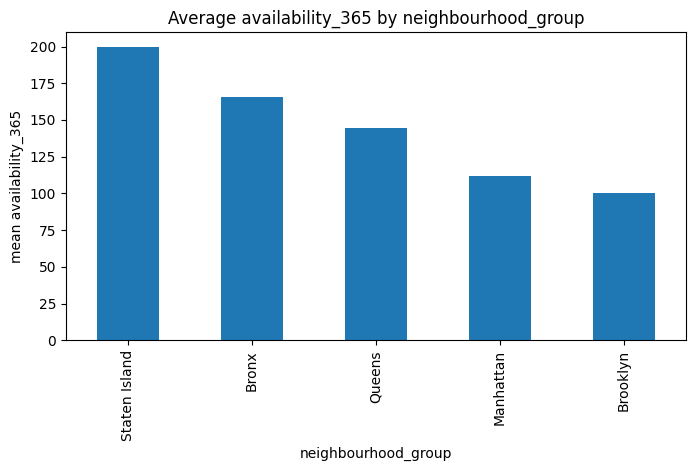

In [22]:
df.groupby("neighbourhood_group")["availability_365"].mean().sort_values(ascending=False).plot(
    kind="bar", figsize=(8, 4), title="Average availability_365 by neighbourhood_group"
)
plt.ylabel("mean availability_365")
plt.show()

# 5 - Suspicious hosts investigation

In [23]:
df["calculated_host_listings_count"].describe(percentiles=[.5, .75, .9, .95, .99])

count    48847.000000
mean         7.149016
std         32.968270
min          1.000000
50%          1.000000
75%          2.000000
90%          5.000000
95%         15.000000
99%        232.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

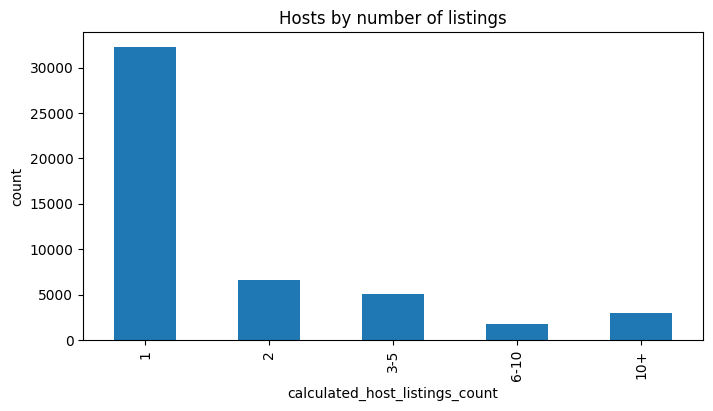

In [24]:
pd.cut(
    df["calculated_host_listings_count"],
    bins=[0, 1, 2, 5, 10, df["calculated_host_listings_count"].max()],
    labels=["1", "2", "3-5", "6-10", "10+"]
).value_counts().sort_index().plot(kind="bar", figsize=(8, 4), title="Hosts by number of listings")
plt.ylabel("count")
plt.show()

In [25]:
df["is_multi_listing_host"] = df["calculated_host_listings_count"] >= 10

df.groupby("is_multi_listing_host")[["number_of_reviews", "availability_365"]].mean()

,number_of_reviews,availability_365
is_multi_listing_host,,
False,24.330501,101.702409
True,8.034624,272.323890


# 6 - SQL (DuckDB)

In [28]:
import duckdb

query = open("../sql/queries.sql").read()
duckdb.sql(query)

┌───────────────────────┬─────────────┬──────────────────┬──────────┐
│ is_multi_listing_host │ avg_reviews │ avg_availability │ listings │
│        boolean        │   double    │      double      │  int64   │
├───────────────────────┼─────────────┼──────────────────┼──────────┤
│ true                  │        8.03 │           272.32 │     3177 │
│ false                 │       24.33 │            101.7 │    45670 │
└───────────────────────┴─────────────┴──────────────────┴──────────┘

# 7 - Export processed data

In [29]:
df.to_csv("../data/processed/AB_NYC_2019_clean.csv", index=False)